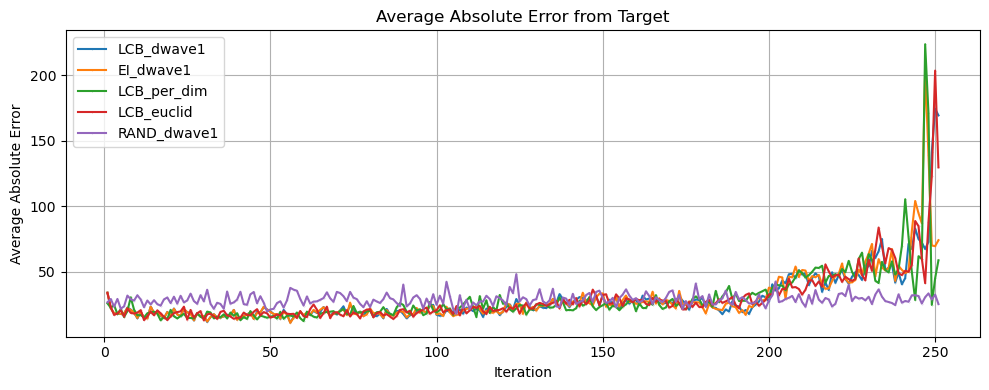

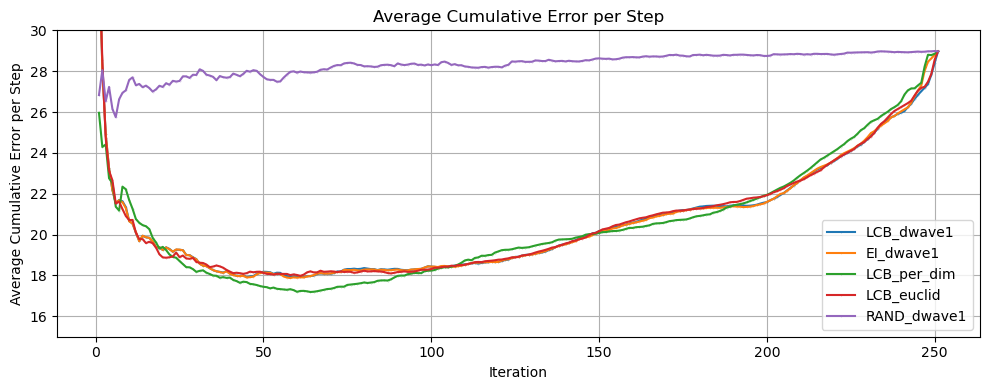

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_avg_absolute_error(results, figsize=(10, 4)):
    """
    複数の結果ファイルについて、平均絶対誤差を同一グラフにプロットします。

    Parameters
    ----------
    results : dict
        キーが凡例ラベル、値が (csv_path, target_value) のタプル。
        CSV は index=run, columns=iter1, iter2,... の形式で、
        各セルに目的関数の予測値が入っているものとします。
    figsize : tuple
        プロットサイズ
    """
    plt.figure(figsize=figsize)
    for label, (csv_path, target) in results.items():
        df_Y = pd.read_csv(csv_path, index_col=0)
        df_error = (df_Y - target).abs()
        avg_error = df_error.mean(axis=0)
        iters = [int(c.replace('iter', '')) for c in df_error.columns]
        plt.plot(iters, avg_error.values, marker='o',markersize = 0.1, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Average Absolute Error")
    plt.title("Average Absolute Error from Target")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_avg_cumulative_per_step_error(results, figsize=(10, 4),ylim=(15, 30)):
    """
    複数の結果ファイルについて、平均累積誤差をイテレーション数で割った
    「1ステップあたり平均誤差」を同一グラフにプロットします。

    Parameters
    ----------
    results : dict
        キーが凡例ラベル、値が (csv_path, target_value) のタプル。
    figsize : tuple
        プロットサイズ
    """
    plt.figure(figsize=figsize)
    for label, (csv_path, target) in results.items():
        df_Y = pd.read_csv(csv_path, index_col=0)
        df_error = (df_Y - target).abs()
        df_cum = df_error.cumsum(axis=1)
        avg_cum = df_cum.mean(axis=0)
        iters = pd.Series([int(c.replace('iter', '')) for c in avg_cum.index], index=avg_cum.index)
        avg_per_step = avg_cum / iters
        plt.plot(iters.values, avg_per_step.values, marker='o',markersize = 0.1 , label=label)
    plt.ylim(ylim)
    plt.xlabel("Iteration")
    plt.ylabel("Average Cumulative Error per Step")
    plt.title("Average Cumulative Error per Step")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ── 使い方例 ────────────────────────────────
results_dwave1 = {
    "LCB_dwave1": ("../../BO_result/target_relative/initsize5_all_methods/initsize5_all_methods_Y_lcb_dwave1.csv", 530.64),
    "EI_dwave1":  ("../../BO_result/target_relative/initsize5_all_methods/initsize5_all_methods_Y_ei_dwave1.csv", 530.64),
    "LCB_per_dim": ("../../BO_result/target_relative/initsize5_all_methods/initsize5_all_methods_Y_lcb_per_dim_dwave1.csv", 530.64), 
    "LCB_euclid": ("../../BO_result/target_relative/initsize5_all_methods/initsize5_all_methods_Y_lcb_euclid_dwave1.csv", 530.64),
    "RAND_dwave1":("../../BO_result/target_relative/initsize5_all_methods/initsize5_all_methods_Y_rand_dwave1.csv", 530.64)

#     # 他の目的関数も同様に追加可能
}
plot_avg_absolute_error(results_dwave1)
plot_avg_cumulative_per_step_error(results_dwave1)


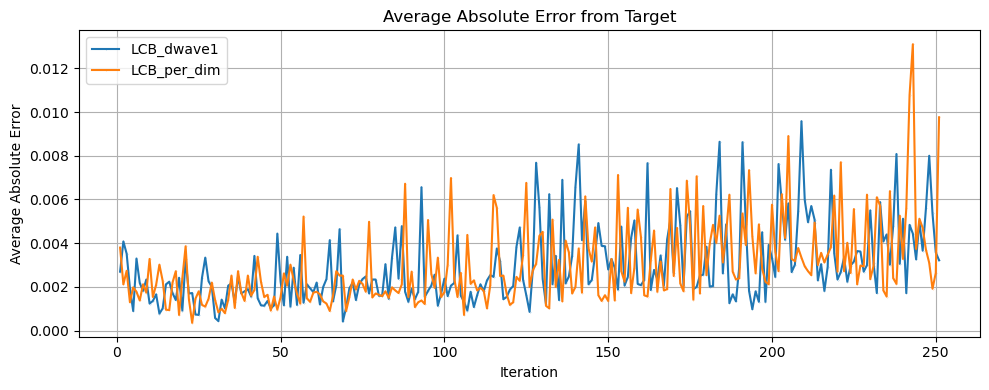

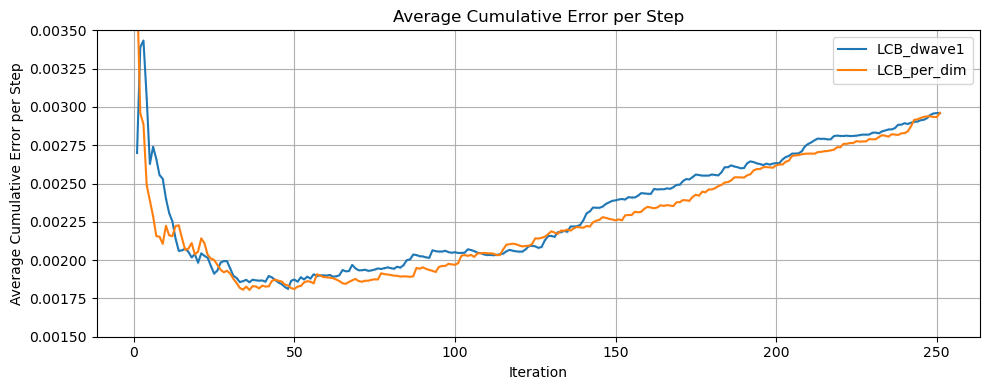

In [ ]:
results_dstrength1 = {
    "LCB_dwave1": ("../../test_results/FP_test_Y_lcb_dstrength1.csv", 0.005),
    "EI_dwave1":  ("../../test_results/FP_test_Y_ei_dstrength1.csv", 0.005),
    "LCB_per_dim": ("../../test_results/FP_test_Y_lcb_per_dim_dstrength1.csv", 0.005), 
    "LCB_euclid": ("../../test_results/FP_test_Y_lcb_euclid_dstrength1.csv", 0.005),
    "RAND_dwave1":("../../test_results/FP_test_Y_rand_dstrength1.csv", 0.005)

#     # 他の目的関数も同様に追加可能
}
plot_avg_absolute_error(results_dstrength1)
plot_avg_cumulative_per_step_error(results_dstrength1, ylim=(0.0015,0.0035))


In [49]:
import pandas as pd
import numpy as np

def load_and_avg(path: str) -> pd.DataFrame:
    """
    累積後悔CSVを読み込み、iter番号で割って平均後悔に変換。
    """
    df = pd.read_csv(path, index_col=0)
    avg = df.copy()
    for col in avg.columns:
        it = int(col.replace('iter', ''))
        avg[col] = df[col] / it
    return avg

def compute_norm(avg_dfs) -> pd.DataFrame:
    """
    複数目的関数の平均後悔DataFrameリストから
    run×iterごとにノルム（二乗和の平方根）を計算。
    """
    sq_sum = avg_dfs[0] ** 2
    for df in avg_dfs[1:]:
        sq_sum += df ** 2
    return np.sqrt(sq_sum)


In [74]:
# ここにご自身のファイルパスをリストで並べてください
input_files = [
    '../../BO_result/target_relative/initsize5_all_methods/initsize5_all_methods_regret_lcb_per_dim_dwave1.csv',
    '../../BO_result/target_relative/initsize5_all_methods/initsize5_all_methods_regret_lcb_per_dim_dstrength1.csv',
    # ... 必要なだけ続ける
]

# 1) 各ファイルの平均後悔を計算
avg_list = [load_and_avg(f) for f in input_files]

# 2) すべての目的関数についてノルムを計算
norm_df = compute_norm(avg_list)

# 3) 結果を表示＆CSV出力
display(norm_df)                # Jupyter上でテーブル表示
# norm_df.to_csv('results/norms.csv', index=True)


,iter1,iter2,iter3,iter4,iter5,iter6,iter7,iter8,iter9,iter10,...,iter242,iter243,iter244,iter245,iter246,iter247,iter248,iter249,iter250,iter251
run1,0.380001,0.367930,0.418595,0.632751,0.639255,0.583703,0.624570,0.688147,0.673731,0.706937,...,1.052140,1.055943,1.057367,1.056525,1.060439,1.086359,1.101734,1.100984,1.102341,1.110564
run2,2.316299,1.469093,1.389665,1.103062,1.172876,1.041165,1.093941,1.043810,1.093307,1.095703,...,1.039465,1.046070,1.065541,1.066920,1.070787,1.096575,1.111855,1.109150,1.110467,1.112623
run3,1.259508,0.831367,0.787517,0.690291,0.653490,0.617884,0.646843,0.626522,0.727265,0.670038,...,1.060826,1.064564,1.065952,1.065065,1.068947,1.094875,1.110241,1.109456,1.111316,1.119498
run4,1.761872,1.279100,2.632467,2.074570,1.735988,1.533884,1.516762,1.417215,1.312944,1.320122,...,1.054798,1.053972,1.050558,1.065734,1.069614,1.095550,1.110919,1.108216,1.109549,1.117734
run5,0.977136,0.974106,1.075414,0.895385,0.791945,0.756267,0.662453,0.651359,0.624794,0.575865,...,1.038313,1.042249,1.061880,1.061006,1.064906,1.090866,1.106258,1.103573,1.104925,1.113127
run6,1.650512,1.233321,1.235835,1.245282,2.677381,2.285381,2.044205,1.848196,1.772520,1.707611,...,1.067168,1.070503,1.071821,1.082702,1.086520,1.101581,1.116950,1.114222,1.116065,1.118215
run7,2.030044,1.175983,0.908022,0.888300,0.855219,0.948583,0.887640,1.099806,1.023722,0.981177,...,1.060399,1.066758,1.070305,1.069353,1.070708,1.096833,1.112309,1.109597,1.117783,1.119084
run8,0.367786,0.545062,0.445186,0.374694,0.422759,0.408112,0.369037,0.520423,0.548041,0.633802,...,1.054724,1.061178,1.064964,1.064100,1.067981,1.093822,1.109139,1.108359,1.110221,1.112381
run9,1.590670,0.977536,1.111244,1.160692,1.024731,0.939832,0.886976,0.884065,0.819828,0.781833,...,1.043702,1.063507,1.069890,1.071249,1.075113,1.101163,1.116588,1.115775,1.117088,1.119242
run10,0.530075,1.072629,0.902110,1.031424,0.850636,0.770412,0.683771,0.808461,0.784628,0.756460,...,1.051787,1.071485,1.077858,1.076922,1.080756,1.106638,1.121955,1.121123,1.122936,1.125054


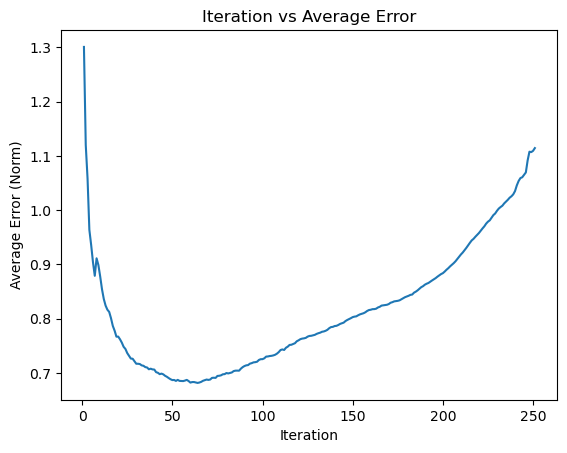

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# ノルム結果のCSVを読み込み

# 各イテレーションでの平均誤差（ノルム）を計算
avg_error = norm_df.mean(axis=0)
iterations = [int(col.replace('iter', '')) for col in avg_error.index]

# プロット
plt.figure()
plt.plot(iterations, avg_error.values)
plt.xlabel('Iteration')
plt.ylabel('Average Error (Norm)')
plt.title('Iteration vs Average Error')
plt.show()


In [76]:
import pandas as pd
import numpy as np

def compute_delta(
    norm_df: pd.DataFrame,
    ignore_iters: int = 10
) -> pd.DataFrame:
    """
    各 run ごとに、
    当該イテレーションのノルムがこれまでの平均ノルムに対して
    どれだけ増減したかを計算します。
    
    - iter1 は常に 0（ただし ignore_iters の範囲は NaN）
    - 最初の ignore_iters イテレーションは NaN（無視）
    - 返り値: 同じ形状の DataFrame (float)
    """
    # 結果用 DataFrame を初期化
    delta = pd.DataFrame(index=norm_df.index,
                         columns=norm_df.columns,
                         dtype=float)

    # 各 run ごとに増減を計算
    for run in norm_df.index:
        for i, col in enumerate(norm_df.columns):
            if i == 0:
                delta.loc[run, col] = 0.0
            else:
                prev_cols = norm_df.columns[:i]
                mean_prev = norm_df.loc[run, prev_cols].mean()
                delta.loc[run, col] = norm_df.loc[run, col] - mean_prev

    # 無視するイテレーションを NaN に設定
    delta.iloc[:, :ignore_iters] = np.nan

    return delta

# 使用例
delta_df = compute_delta(norm_df, ignore_iters=10)
display(delta_df)


formatted = delta_df.applymap(lambda x: f"{x:+.3f}" if pd.notnull(x) else "")

# CSV 出力
formatted.to_csv('FP_delta.csv', index=True)



,iter1,iter2,iter3,iter4,iter5,iter6,iter7,iter8,iter9,iter10,...,iter242,iter243,iter244,iter245,iter246,iter247,iter248,iter249,iter250,iter251
run1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.289216,0.291825,0.292047,0.290008,0.292738,0.317468,0.331559,0.329471,0.329505,0.336410
run2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.240493,0.246104,0.264562,0.264857,0.267643,0.292343,0.306440,0.302499,0.302601,0.303547
run3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.314617,0.317055,0.317138,0.314951,0.317548,0.342185,0.356166,0.353944,0.354383,0.361147
run4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.166069,0.164556,0.160465,0.174984,0.178149,0.203361,0.217907,0.214326,0.214797,0.222123
run5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.304262,0.306941,0.325308,0.323101,0.325682,0.350319,0.364292,0.360138,0.360043,0.366806
run6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.160930,0.163601,0.164245,0.174453,0.177559,0.191898,0.206491,0.202930,0.203958,0.205292
run7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.221272,0.226716,0.229330,0.227439,0.227866,0.253064,0.267516,0.263725,0.270852,0.271069
run8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.325247,0.330357,0.332783,0.330556,0.333088,0.357574,0.371444,0.369166,0.369545,0.370227
run9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.197470,0.216459,0.221951,0.222401,0.225357,0.250491,0.264902,0.263021,0.263277,0.264378
run10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.250860,0.269522,0.274786,0.272724,0.275444,0.300206,0.314309,0.312209,0.312769,0.313635
